# Load metrics from Prometheus

Default API: **`http://178.104.69.73:9090`**. Override with **`PROMETHEUS_URL`** in the next cell or in the shell.

Run Jupyter with **working directory** = the `data-analysis` folder (the one that contains `src/`).

In [1]:
import os
import sys
from pathlib import Path

# Project root = folder that contains src/ (works if cwd is data-analysis or data-analysis/notebooks)
_cwd = Path.cwd()
ROOT = _cwd
for _ in range(4):
    if (ROOT / "src" / "prometheus_io.py").is_file():
        break
    ROOT = ROOT.parent
else:
    raise FileNotFoundError("Could not find src/prometheus_io.py — cd into data-analysis and start Jupyter from there.")
sys.path.insert(0, str(ROOT))

# --- Prometheus HTTP API (default: thesis VM) ---
os.environ["PROMETHEUS_URL"] = os.environ.get("PROMETHEUS_URL", "http://178.104.69.73:9090")
# os.environ["PROMETHEUS_URL"] = "http://OTHER_HOST:9090"

from src.prometheus_io import prom_query_range, prom_query_instant, test_connection
import src.prometheus_io as pio

pio.PROMETHEUS_URL = os.environ["PROMETHEUS_URL"].rstrip("/")
BASE = pio.PROMETHEUS_URL
print("Prometheus:", BASE)
print("Connection OK:", test_connection(BASE))

Prometheus: http://178.104.69.73:9090
Connection OK: True


In [2]:
from datetime import datetime, timezone, timedelta

import matplotlib.pyplot as plt
import pandas as pd

# UTC window — adjust to your load test
end = datetime.now(timezone.utc)
start = end - timedelta(hours=1)
STEP = "15s"
print(start, "→", end)

2026-03-22 15:11:37.050649+00:00 → 2026-03-22 16:11:37.050649+00:00


## Scrape health: `up`

In [3]:
df_up = prom_query_range("up", start, end, STEP, base_url=BASE)
df_up.head()

,"up {'instance': '178.104.73.186:9091', 'job': 'chat-monolith'}"
2026-03-22 15:49:52.051000118+00:00,1.0
2026-03-22 15:50:07.051000118+00:00,1.0
2026-03-22 15:50:22.051000118+00:00,1.0
2026-03-22 15:50:37.051000118+00:00,1.0
2026-03-22 15:50:52.051000118+00:00,1.0


## Backend CPU (`process_cpu_usage`)
Change `JOB` to your Prometheus `job` label (e.g. `chat-monolith`).

In [4]:
JOB = "chat-monolith"

df_cpu = prom_query_range(
    f'process_cpu_usage{{job="{JOB}"}}',
    start,
    end,
    STEP,
    base_url=BASE,
)
df_cpu.head()

,"process_cpu_usage {'instance': '178.104.73.186:9091', 'job': 'chat-monolith'}"
2026-03-22 15:49:52.051000118+00:00,0.001671
2026-03-22 15:50:07.051000118+00:00,0.001675
2026-03-22 15:50:22.051000118+00:00,0.001676
2026-03-22 15:50:37.051000118+00:00,0.002342
2026-03-22 15:50:52.051000118+00:00,0.001676


## k6 (only when a test is running / remote-writing)

In [5]:
df_http = prom_query_range(
    'sum(rate(k6_http_reqs_total{scenario="http_senders"}[1m]))',
    start,
    end,
    STEP,
    base_url=BASE,
)
df_ws = prom_query_range(
    'sum(rate(k6_ws_msgs_received_total{scenario="ws_receivers"}[1m]))',
    start,
    end,
    STEP,
    base_url=BASE,
)
df_vus = prom_query_range(
    'sum(k6_scenario_active_vus{scenario="http_senders"})',
    start,
    end,
    STEP,
    base_url=BASE,
)

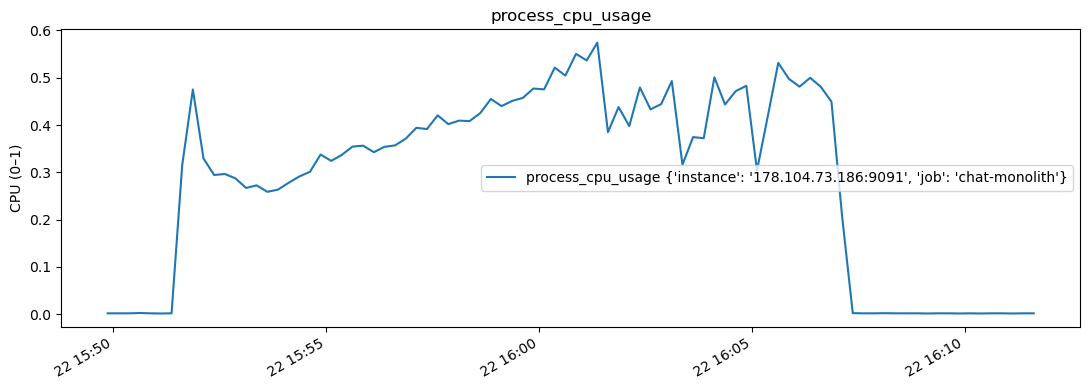

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
if not df_cpu.empty:
    df_cpu.plot(ax=ax, legend=True)
ax.set_title("process_cpu_usage")
ax.set_ylabel("CPU (0–1)")
fig.tight_layout()
plt.show()

## Save CSV under `data/raw/`

In [ ]:
out_dir = ROOT / "data" / "raw"
out_dir.mkdir(parents=True, exist_ok=True)
stamp = start.strftime("%Y%m%d_%H%M")
if not df_cpu.empty:
    p = out_dir / f"cpu_{stamp}.csv"
    df_cpu.to_csv(p)
    print("Saved", p)